In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

L = 0.242e-6
C = 96.8e-12
Z0 = np.sqrt(L / C) # characteristic impedance

vp = 1 / np.sqrt(L * C) # wave velocity
f = 100e6 # frequency
lambda_wave = vp / f # wavelength
print(lambda_wave)
dx = lambda_wave / 20
dt = dx / vp

print(dx)
print(dt)

# it reaches the end x = 20 

x_max = 20 # transmission line length
t_max = 200e-9 # final time

print(x_max / vp)


stable_condition = vp * dt / dx
print(stable_condition)

coeff_V = dt / (C * dx)
coeff_I = dt / (L * dx)

# Parâmetros de grade
nx = int(x_max / dx) + 1
nt = int(t_max / dt) + 1
print(nt)

# Inicialização da matriz de potencial V[tempo, espaço]
V = np.zeros((nt, nx))
I = np.zeros((nt, nx))

# condição inicial
initial_V = np.zeros(nx)
initial_I = np.zeros(nx)

V[0, :] = initial_V
I[0, :] = initial_I

# lanca uma senoide em x = 0
for n in range(nt):
    V[n, 0] = 1 * np.sin(2 * np.pi * f * n * dt)

# Primeiro passo de tempo
for i in range(1, nx - 1):
    V[1, i] = V[0, i]

# Loop Principal
for n in range(1, nt - 1):
    V[n+1, 1:-1] = V[n-1, 1:-1] - coeff_V * (I[n, 2:] - I[n, :-2])
    I[n+1, 1:-1] = I[n-1, 1:-1] - coeff_I * (V[n, 2:] - V[n, :-2])

    # condições de contorno
    V[n+1, -1] = 0 # curto circuito em x = 20



2.0661157024793386
0.10330578512396693
5e-10
9.68e-08
1.0000000000000002
400


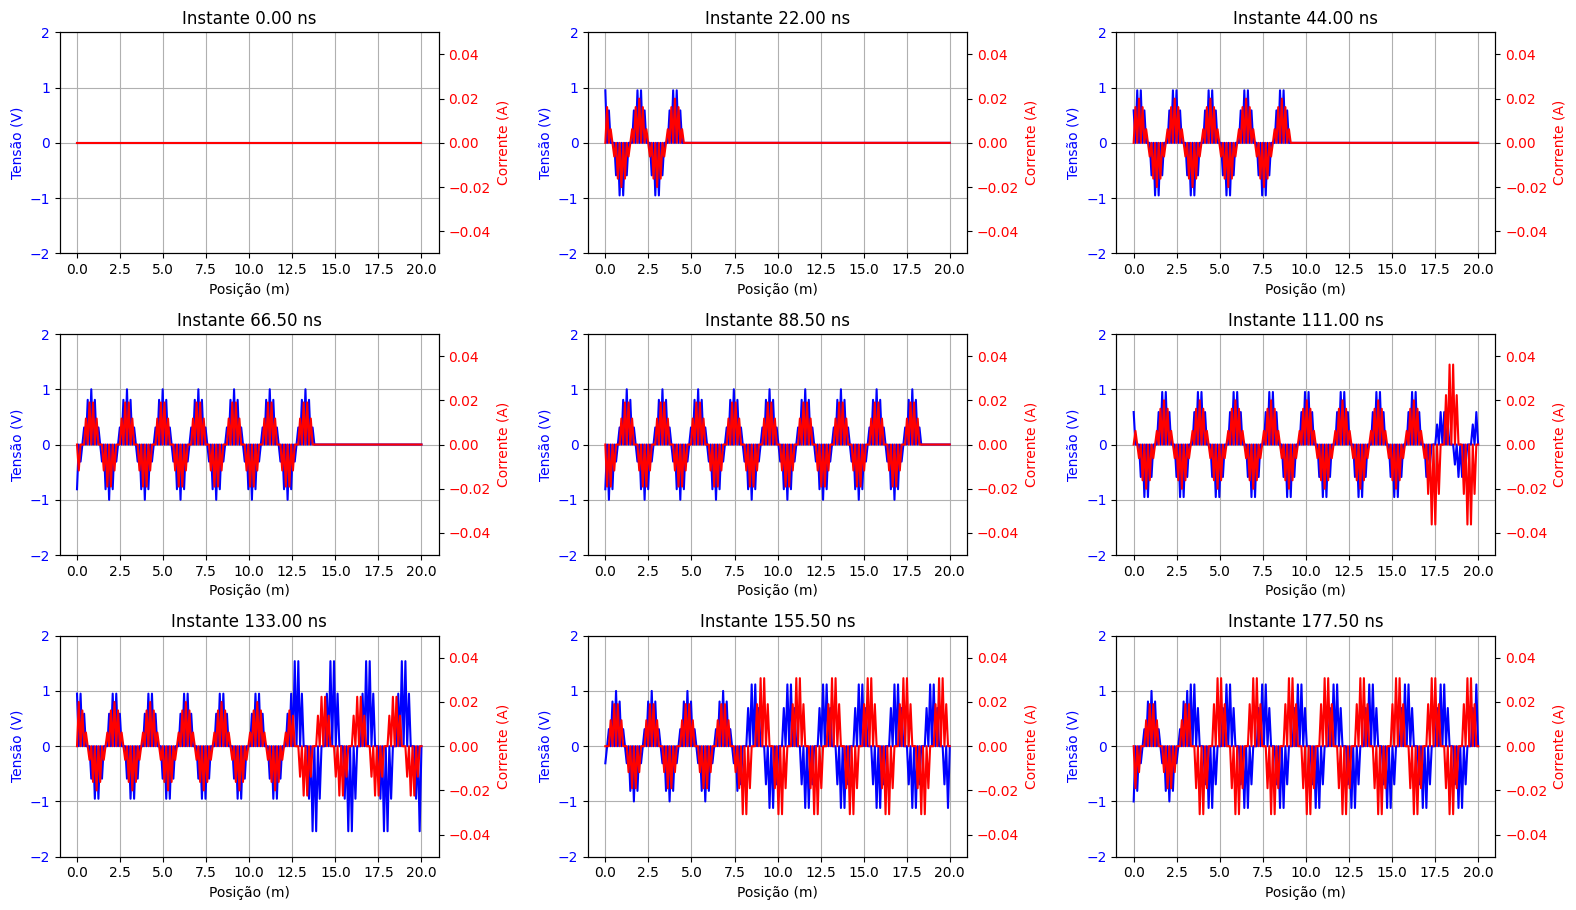

In [64]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10))

x = np.linspace(0, x_max, nx)

t_list = []
for i in range(9):
    t_list.append(int(i * nt / 9))

# t_list = [150, 160, 170, 180, 190, 200, 210, 220, 230]

for i, ax in enumerate(axes.flatten()):
    ax.plot(x, V[t_list[i], :], color='blue', label='Tensão (V)')
    ax.set_title(f'Instante {t_list[i] * dt * 1e9:.2f} ns')      # Set a title for each subplot
    ax.set_xlabel('Posição (m)')
    ax.set_ylabel('Tensão (V)', color='blue')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True)

    ax2 = ax.twinx()
    ax2.plot(x, I[t_list[i], :], color='red', label='Corrente (A)')
    ax2.set_ylabel('Corrente (A)', color='red')
    ax2.tick_params(axis='y', labelcolor='r')

    ax.set_ylim(-2, 2)
    ax2.set_ylim(-0.05, 0.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle

plt.show()

In [66]:
print(x_max)
print(nx)

20
194


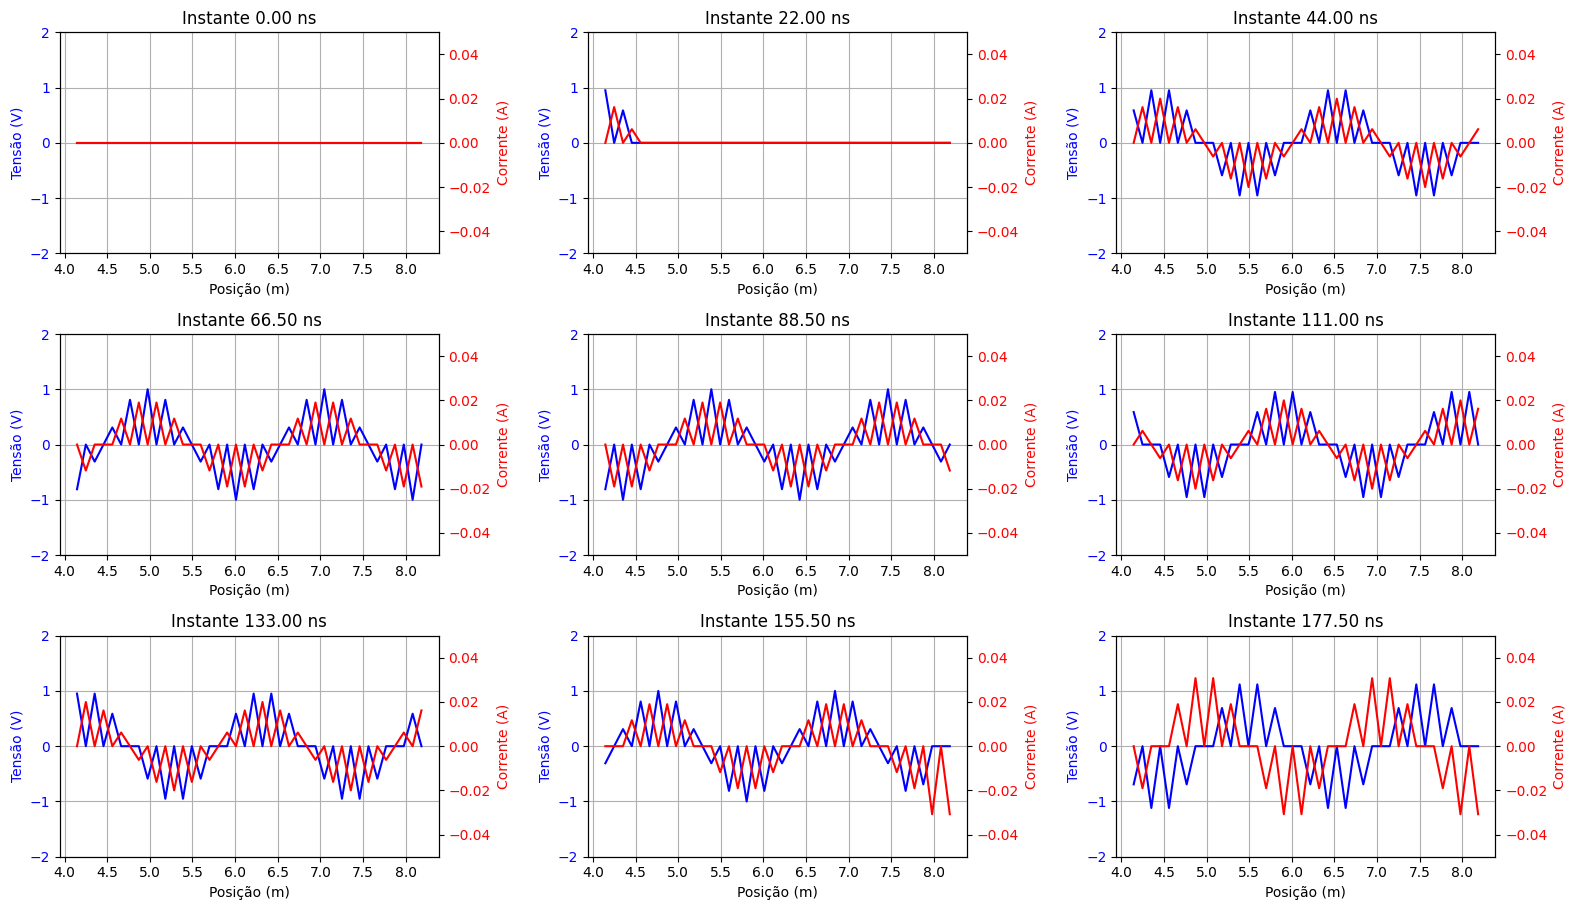

In [67]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10))

x = np.linspace(0, x_max, nx)
x_range = range(40,80)

t_list = []
for i in range(9):
    t_list.append(int(i * nt / 9))

# t_list = [150, 160, 170, 180, 190, 200, 210, 220, 230]

for i, ax in enumerate(axes.flatten()):
    ax.plot(x[x_range], V[t_list[i], x_range], color='blue', label='Tensão (V)')
    ax.set_title(f'Instante {t_list[i] * dt * 1e9:.2f} ns')      # Set a title for each subplot
    ax.set_xlabel('Posição (m)')
    ax.set_ylabel('Tensão (V)', color='blue')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True)

    ax2 = ax.twinx()
    ax2.plot(x[x_range], I[t_list[i], x_range], color='red', label='Corrente (A)')
    ax2.set_ylabel('Corrente (A)', color='red')
    ax2.tick_params(axis='y', labelcolor='r')

    ax.set_ylim(-2, 2)
    ax2.set_ylim(-0.05, 0.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle

plt.show()